# Notebook to build Bayesian inference based normative model that explains in-vivo surround modulation results in Fu et al. 2026: Statistics of natural scenes shape contextual modulation in the visual cortex

### Notebook goals:
1. Show how to build the normative model
2. Create the stimuli (ME, MEI + completing surround, MEI + disruptive surround)
3. Perform posterior inference via sampling to get neural activity to stimuli

Please refer to ./plots.ipynb to visualize the results and reproduce the plots accompanying the paper

In [ ]:
from pathlib import Path
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import (
    ExpPatternCompletionModel,
    BinaryPatternCompletionModel,
)
from probcs.experiment_running.exc_experiment import (
    center_surround_experiment,
    create_stimuli,
)
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior
import pickle


seed = 42
rng = np.random.default_rng(seed)

## Build the model

In [ ]:
# Set model parameters

exc_images = get_excitatory_images()    # To use as PFs in the model
vmin = exc_images.min()
vmax = exc_images.max()
# Choose a subset of them
patterns = exc_images[:10]

G_dim = len(patterns)
G_prob = 0.5
I_sigma = 100
patterns_offset = 0

offset_x_1 = 0
offset_x_2 = 1
scale_x = 0.1
exponent_x = 3
zero_threshold_x = 0.00

G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 500
n_draws = 500
n_chains = 4
n_cores = 4

In [ ]:
# Create custom G to x mapping
# Each G maps strongly to one x, weakly to others
# This controls feedback from G to x

g_x_mapping = np.zeros((G_dim * 9, G_dim)) + 0.05

for j in range(0, G_dim * 9, G_dim):
    for i in range(G_dim):
        g_x_mapping[i + j, i] = 0.8

In [ ]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    offset_x_1=offset_x_1,
    offset_x_2=offset_x_2,
    scale_x=scale_x,
    exponent_x=exponent_x,
    zero_threshold_x=zero_threshold_x,
    g_x_mapping=g_x_mapping,
)

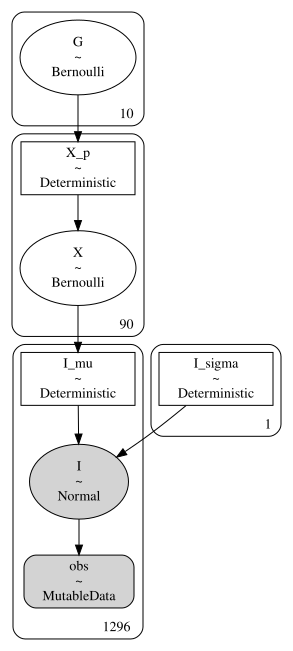

In [ ]:
# Visualize model structure
pm.model_to_graphviz(model.prob_model)

## Create stimuli: MEIs + completing and disruptive surrounds

In [21]:
(
    MEIs,
    completing_patterns,
    disrupting_patterns_1,
    disrupting_patterns_2,
    disrupting_pattern_indices,
) = create_stimuli(patterns)

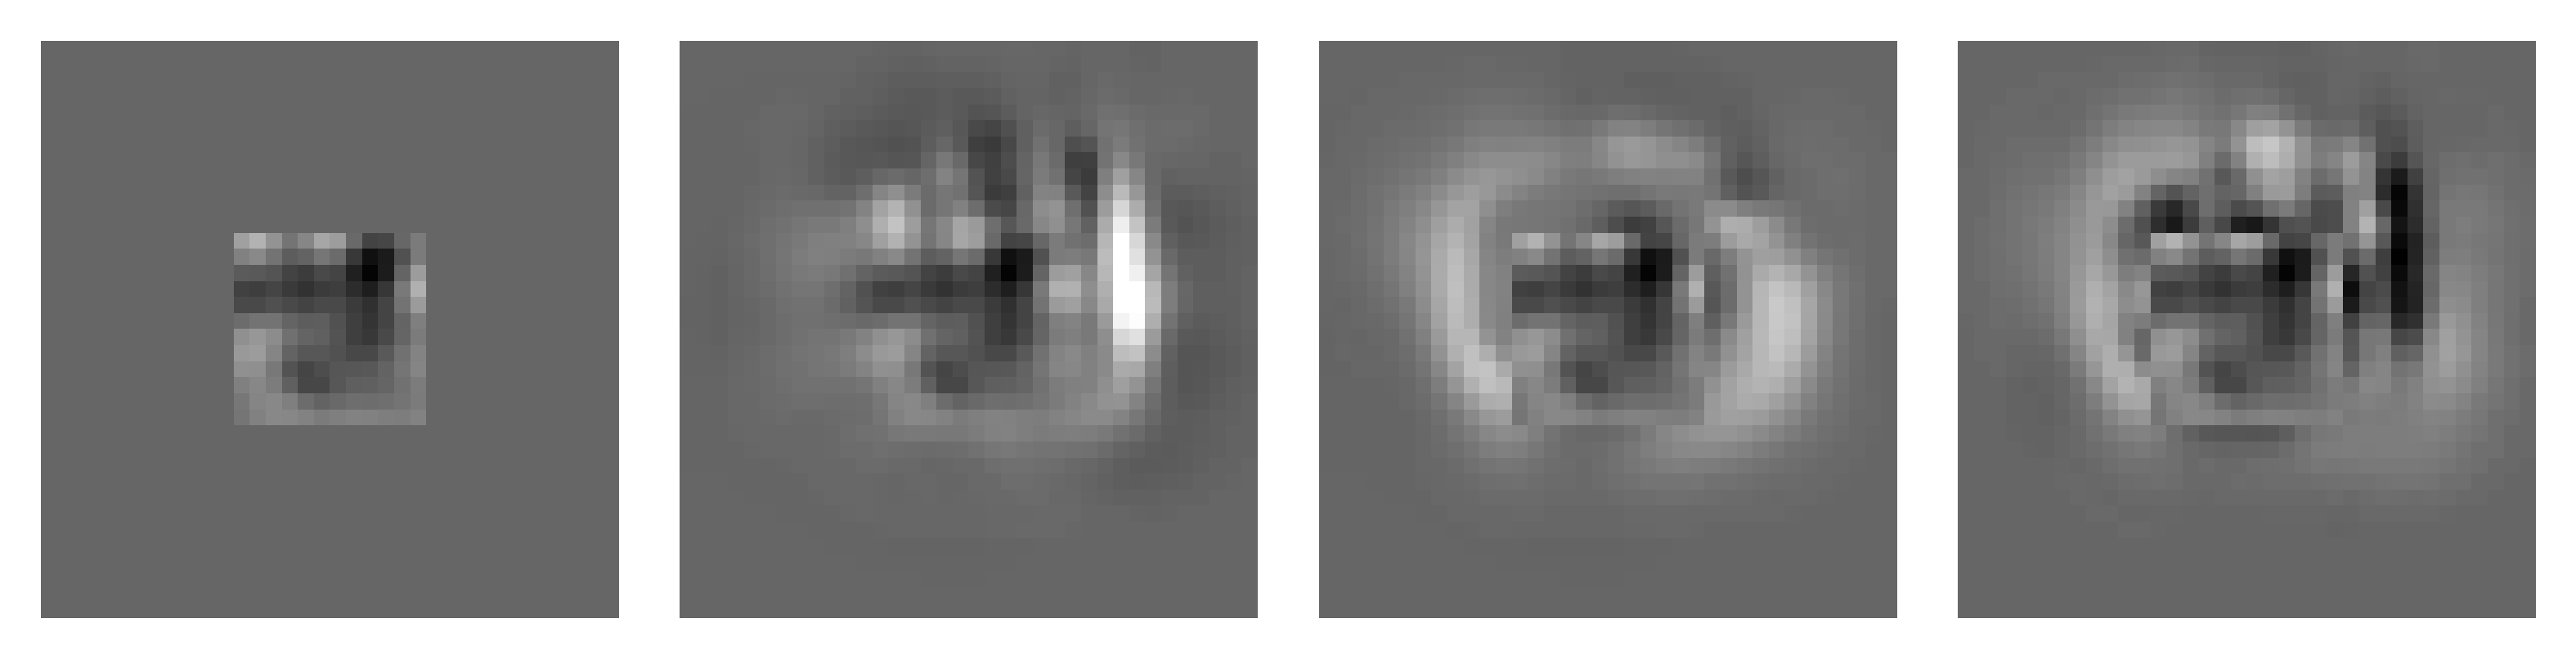

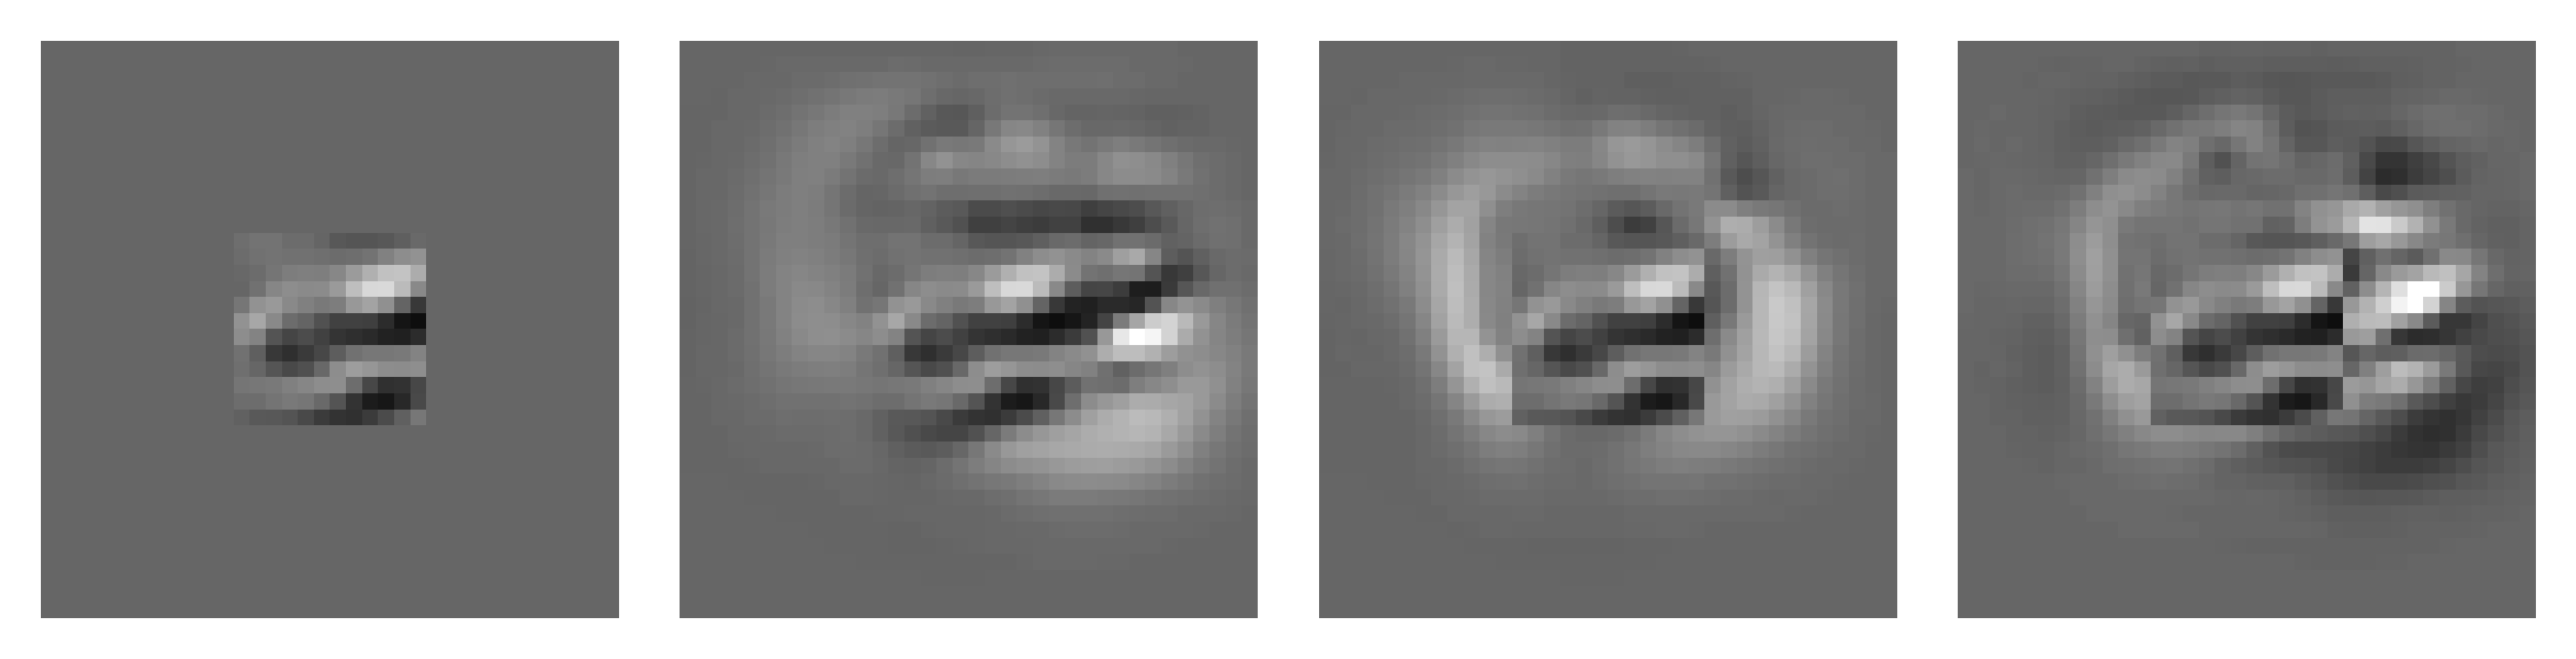

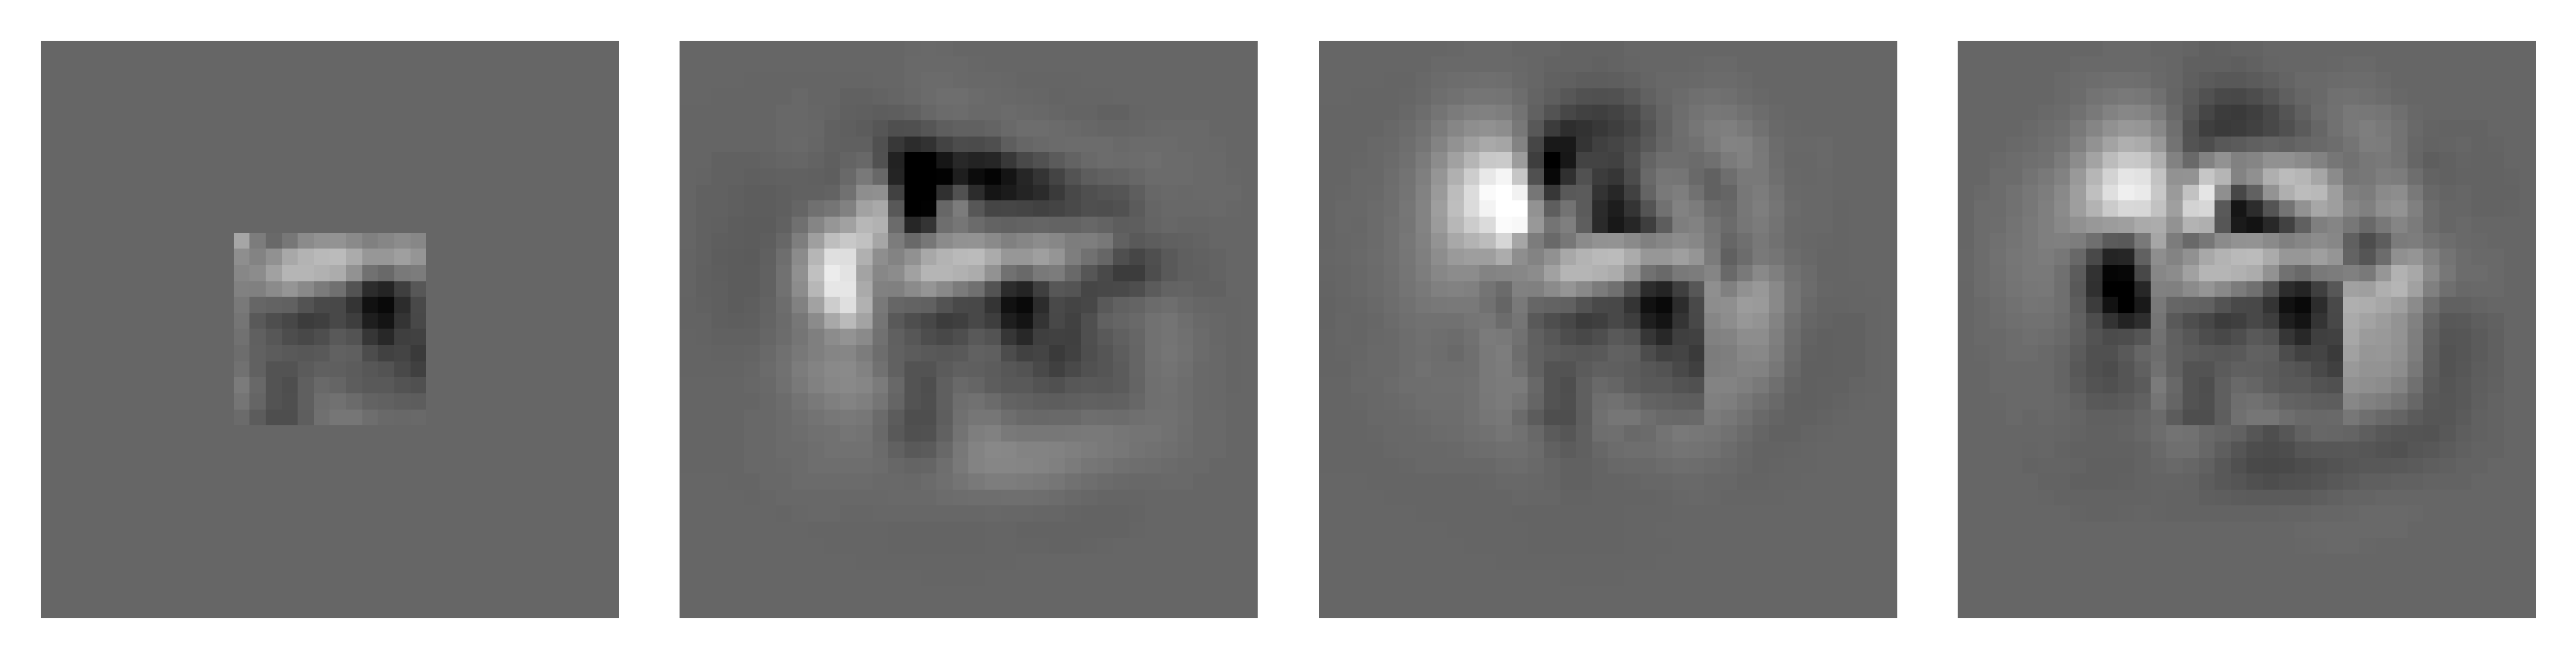

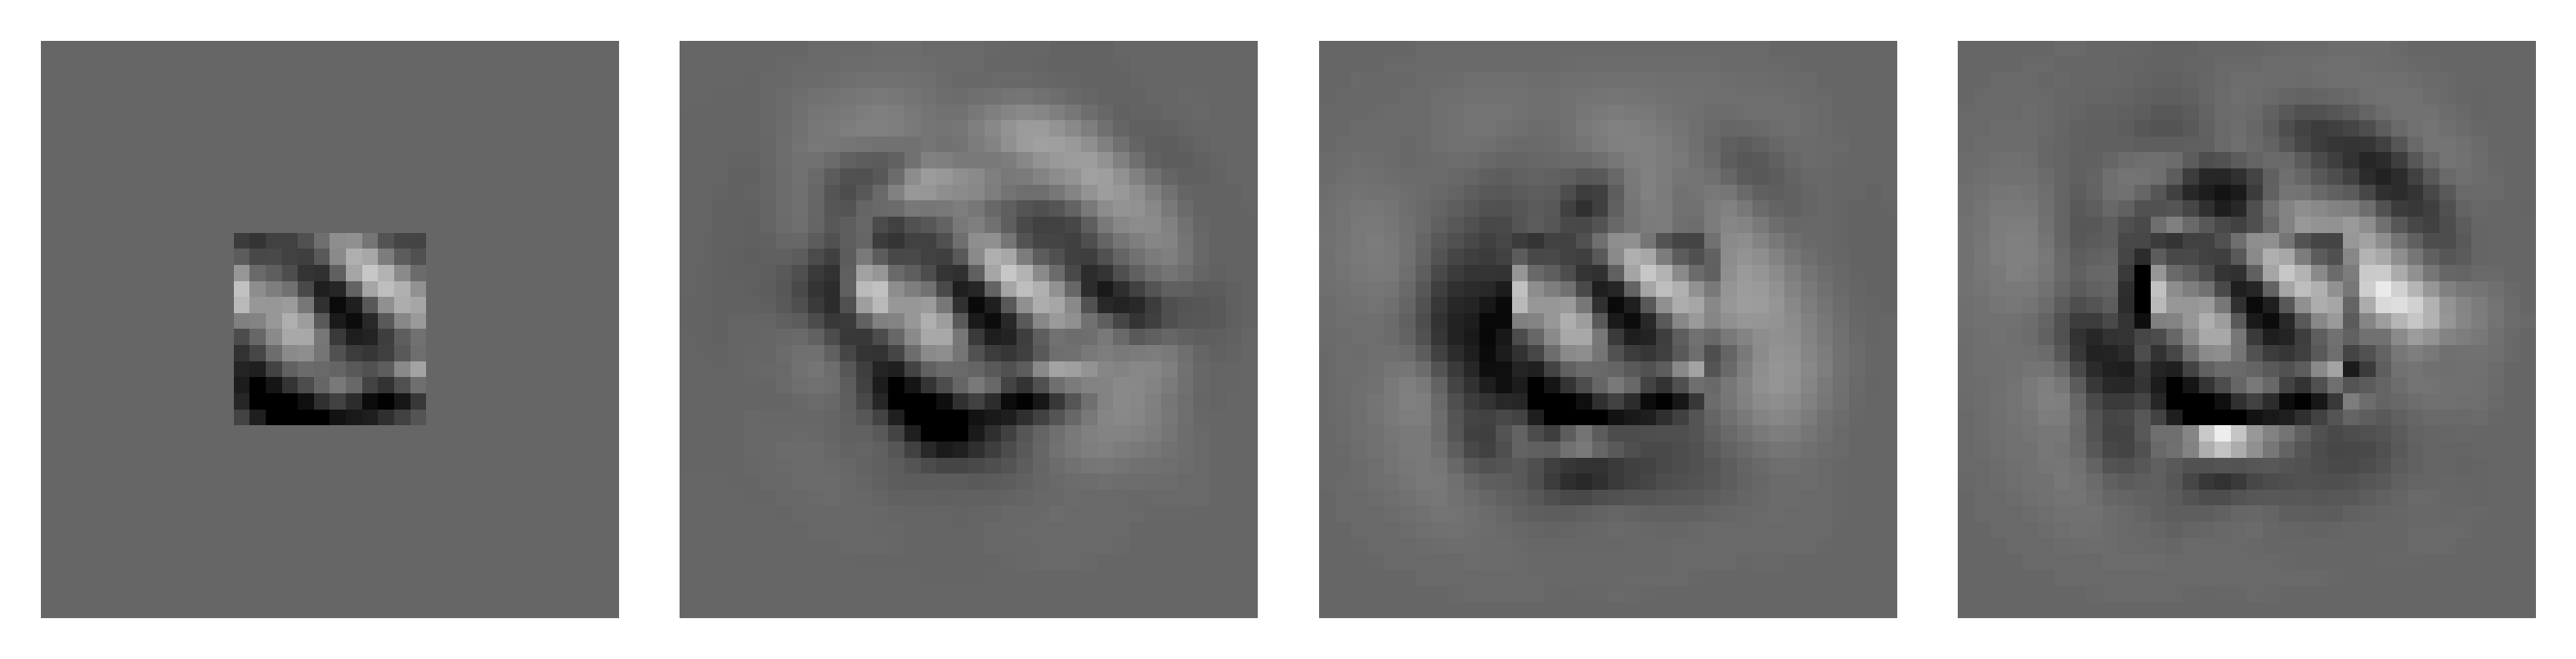

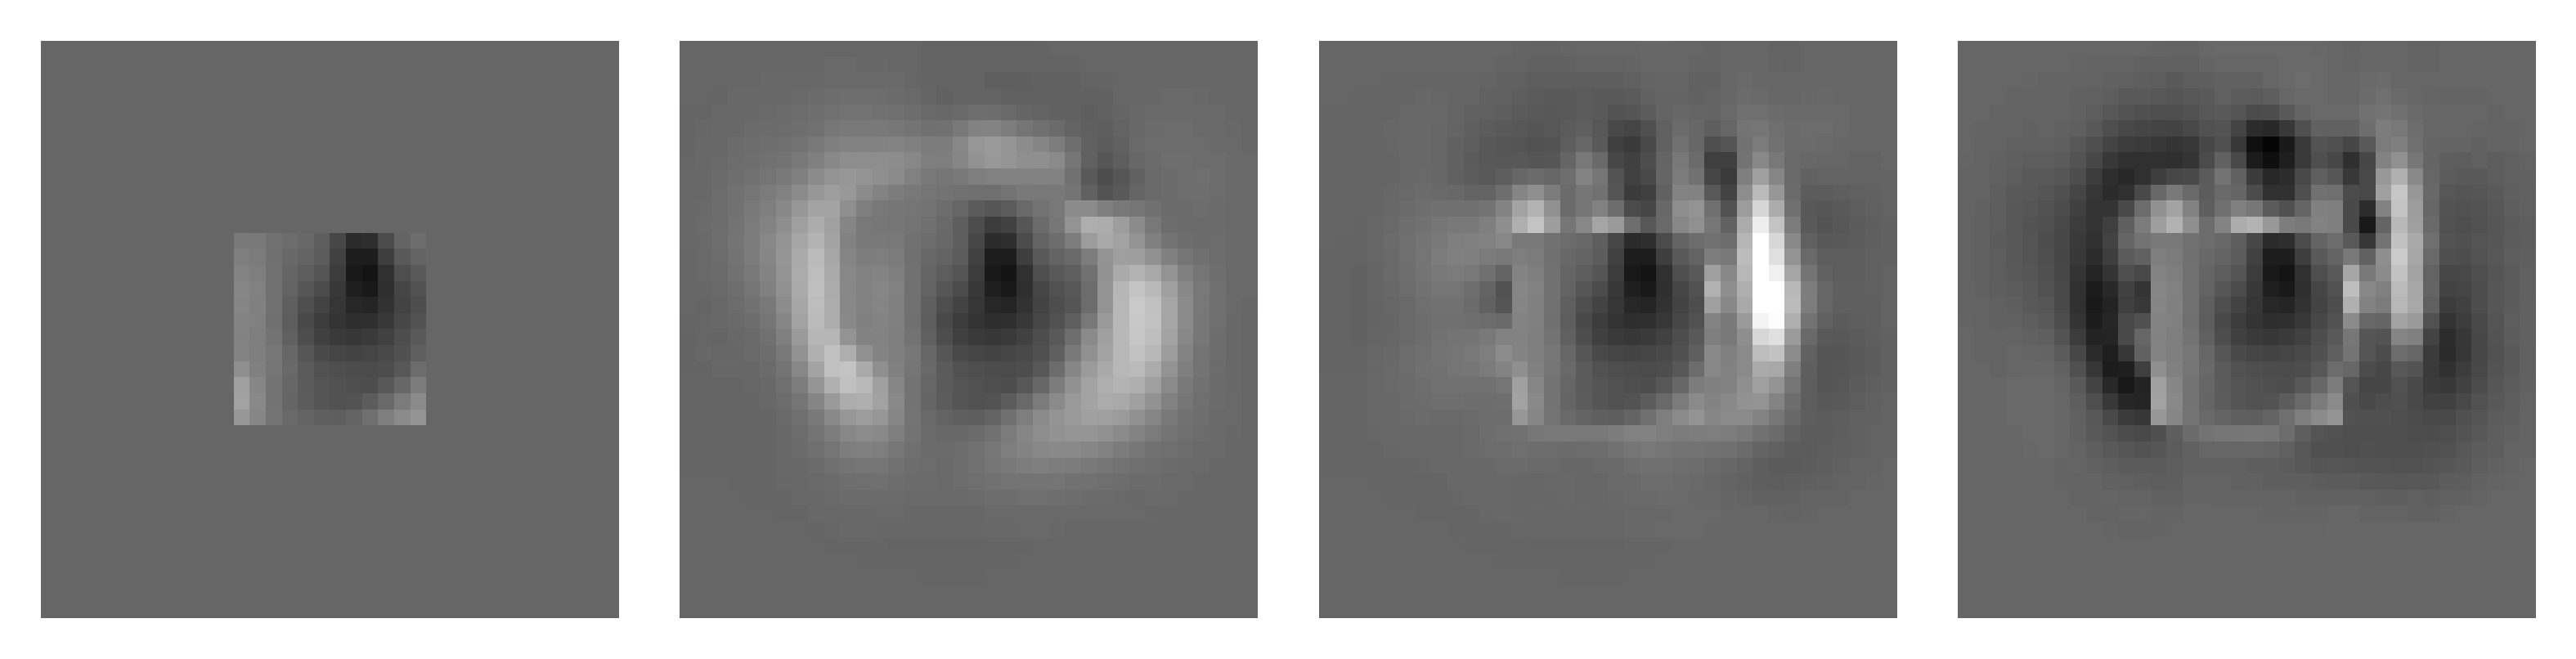

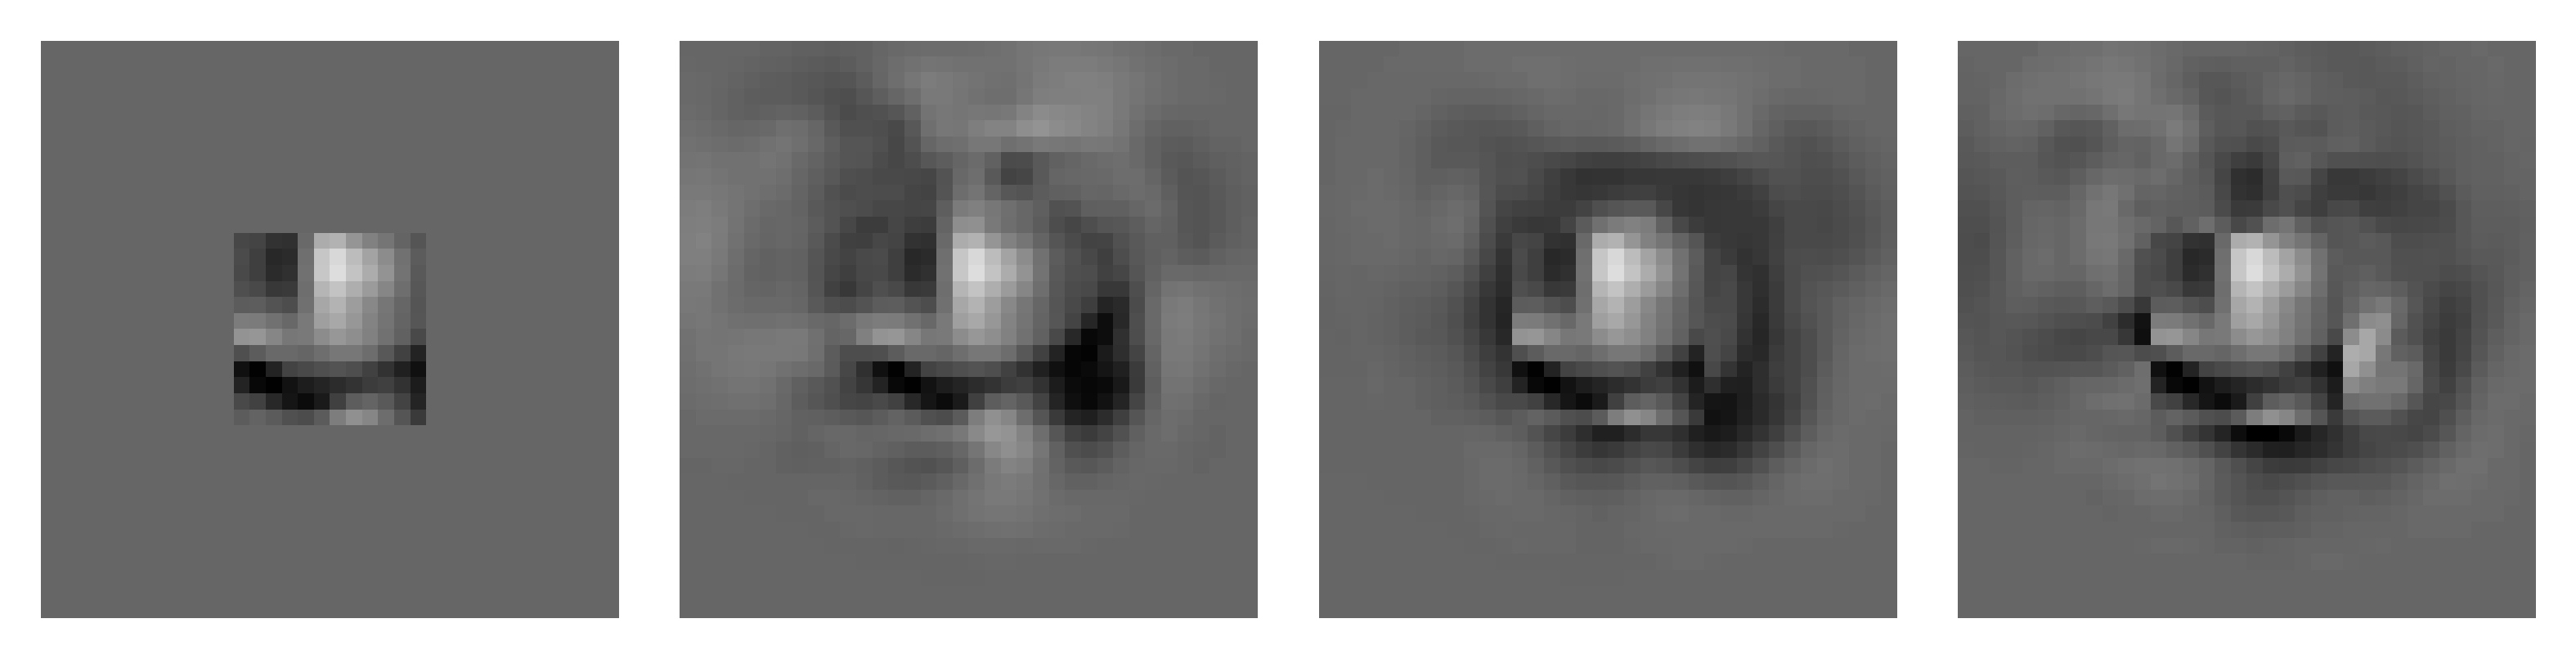

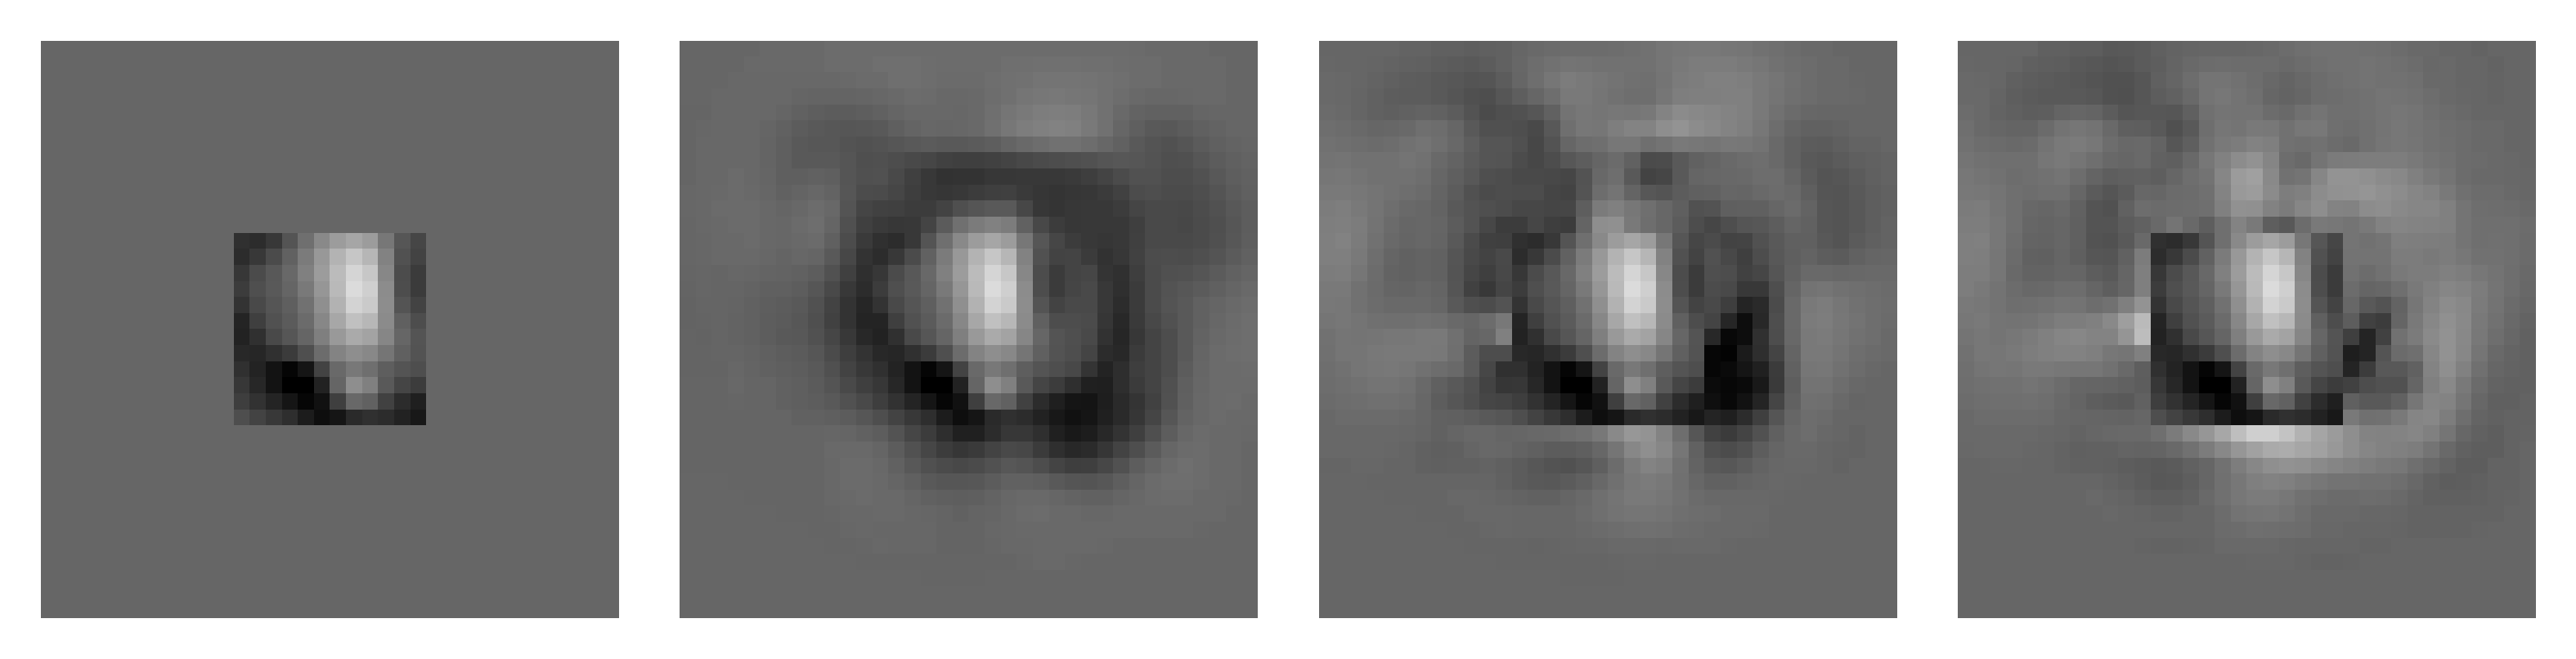

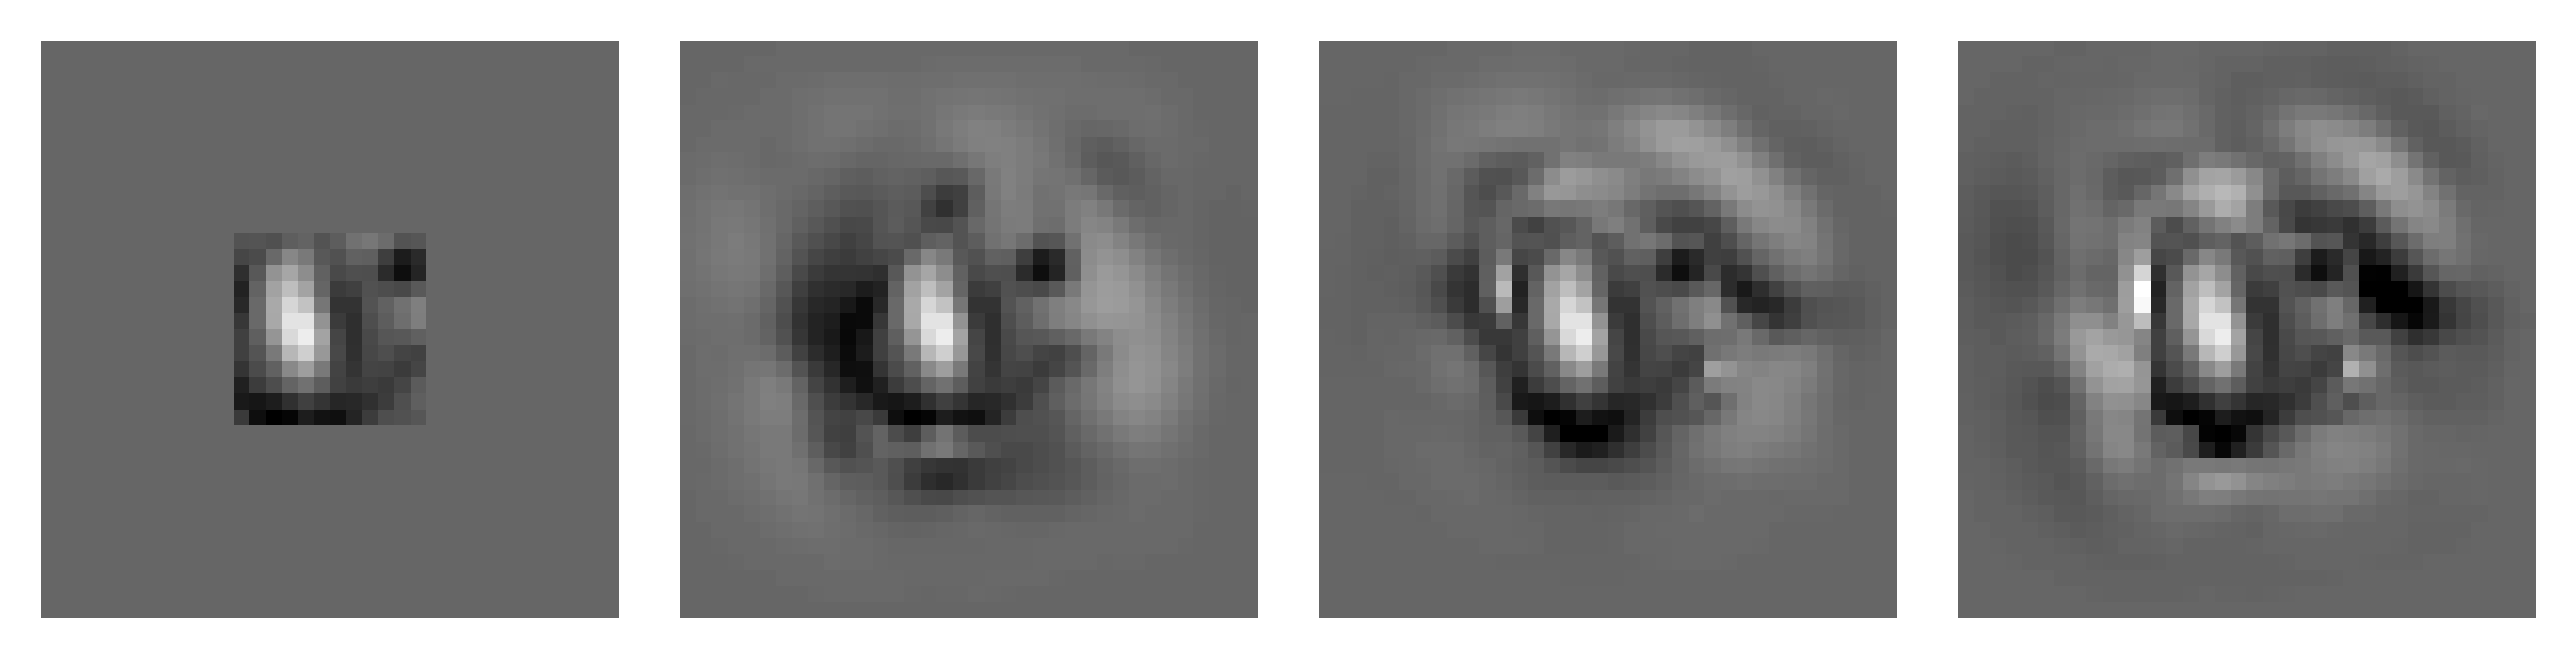

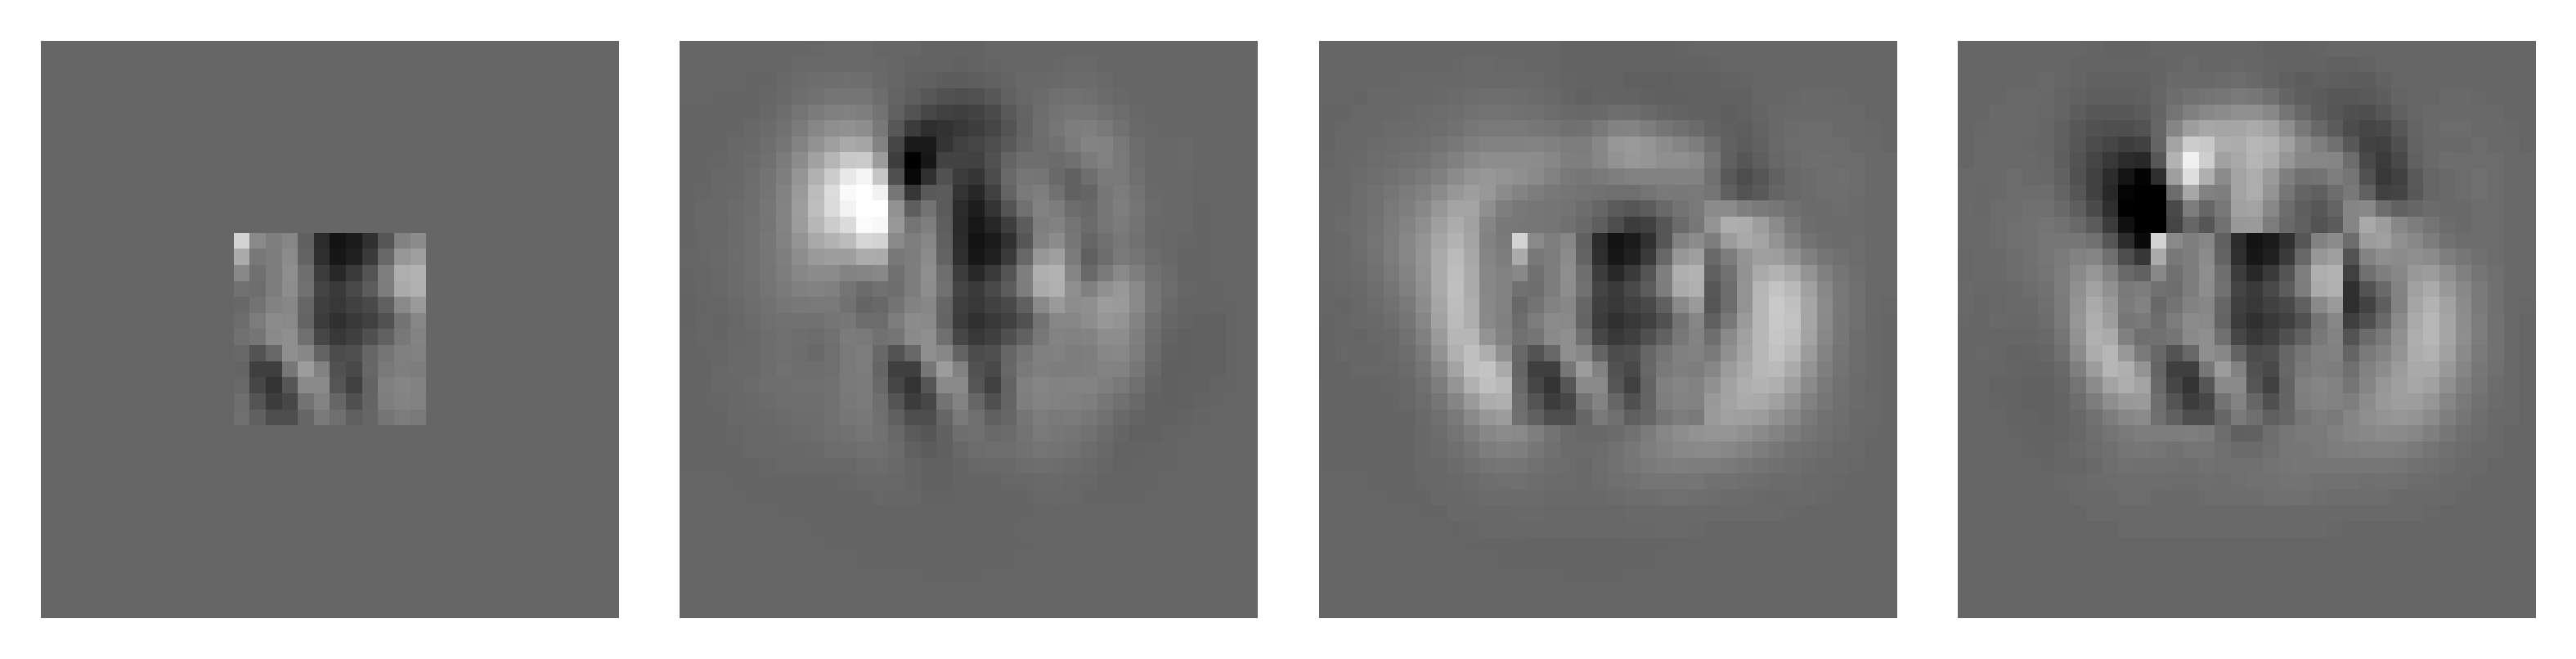

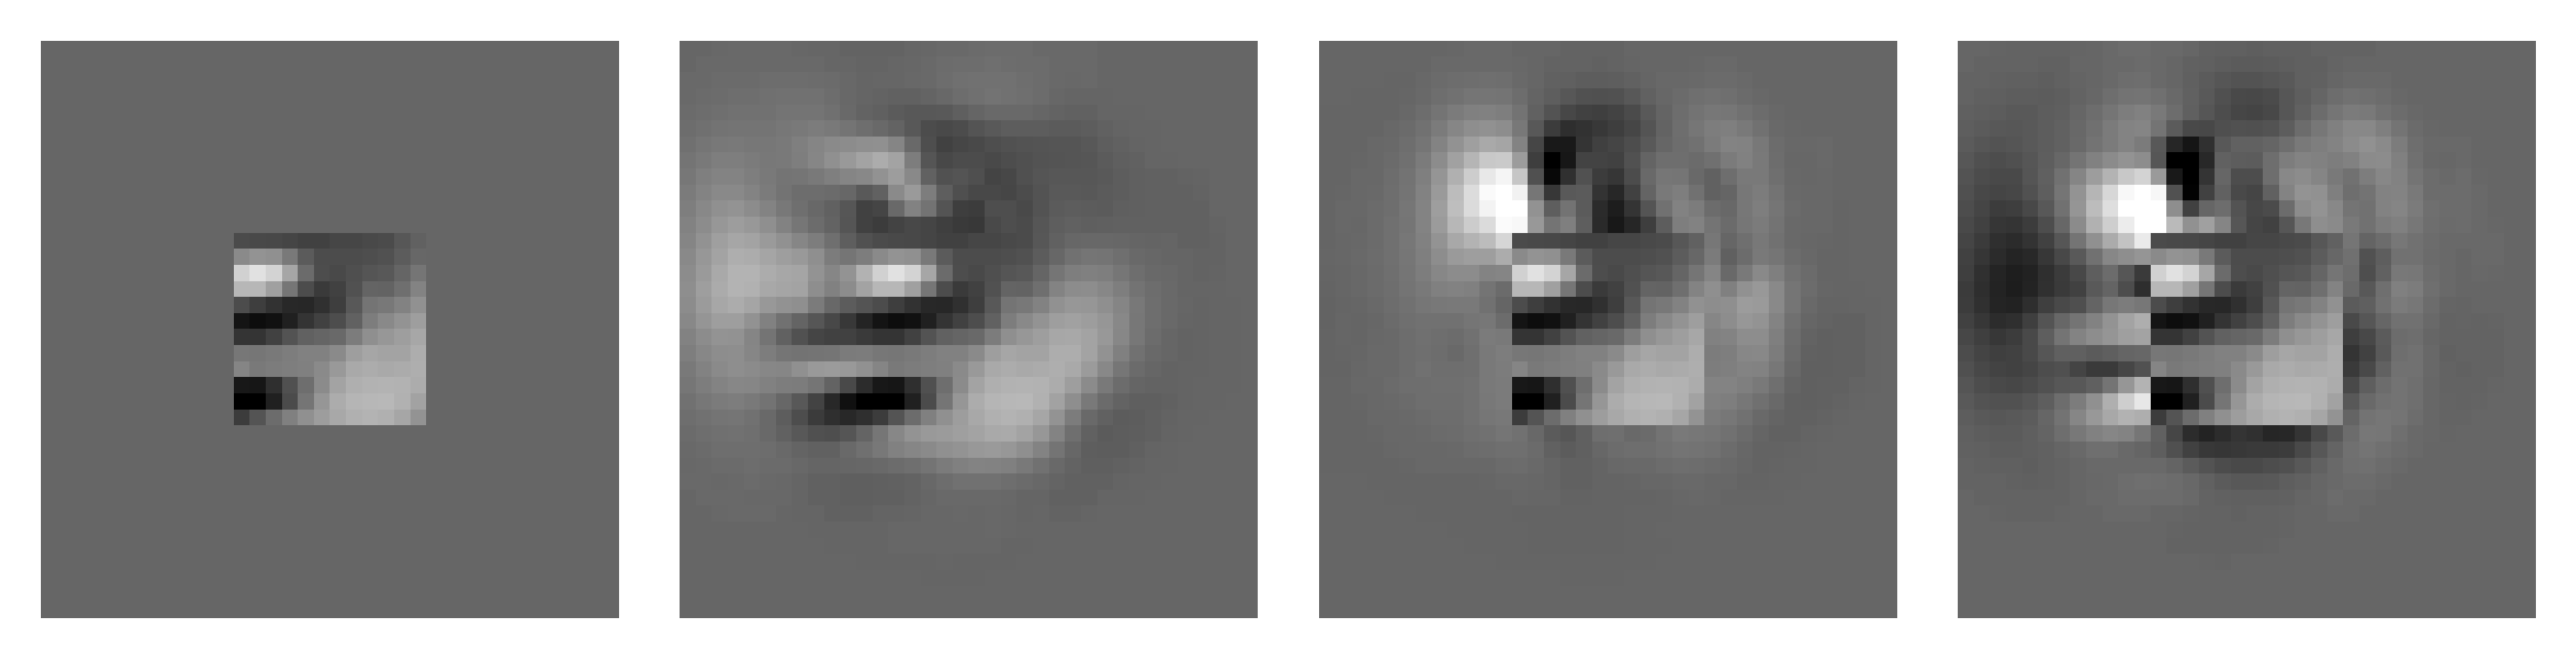

In [ ]:
# Take a look at the stimuli
# 1st col: MEI
# 2nd col: completing pattern
# 3rd col: disrupting pattern 1
# 4th col: disrupting pattern 2 (created by subtracting the surround of completing pattern from disrupting pattern 1)

for idx, (
    MEI,
    completing_pattern,
    disrupting_pattern_1,
    disrupting_pattern_2,
) in enumerate(
    zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2)
):
    fig, axs = plt.subplots(1, 4, dpi=500)
    axs[0].imshow(MEI * 2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern * 2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1 * 2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2 * 2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")
    fig.tight_layout()
    fig.savefig(f"stimuli_{idx}.pdf")

## Perform inference in the probabilistic model and store results

Note that depending on the number of stimuli and number of samples to be drawn, this step could take long (Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took roughly 1 minute)

In [23]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(
    MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2
):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    all_idata.append(idata_set)
    # break

Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 73 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 77 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 77 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 78 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


...

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 78 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 74 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 75 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 77 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 81 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
# Save results

results = [all_idata, G_dim, disrupting_pattern_indices]

# uncomment to save
# with open(f"results_{G_dim}_{n_draws}.pkl", "wb") as f:
#     pickle.dump(results, f)

## Extra: visualize all model PFs 

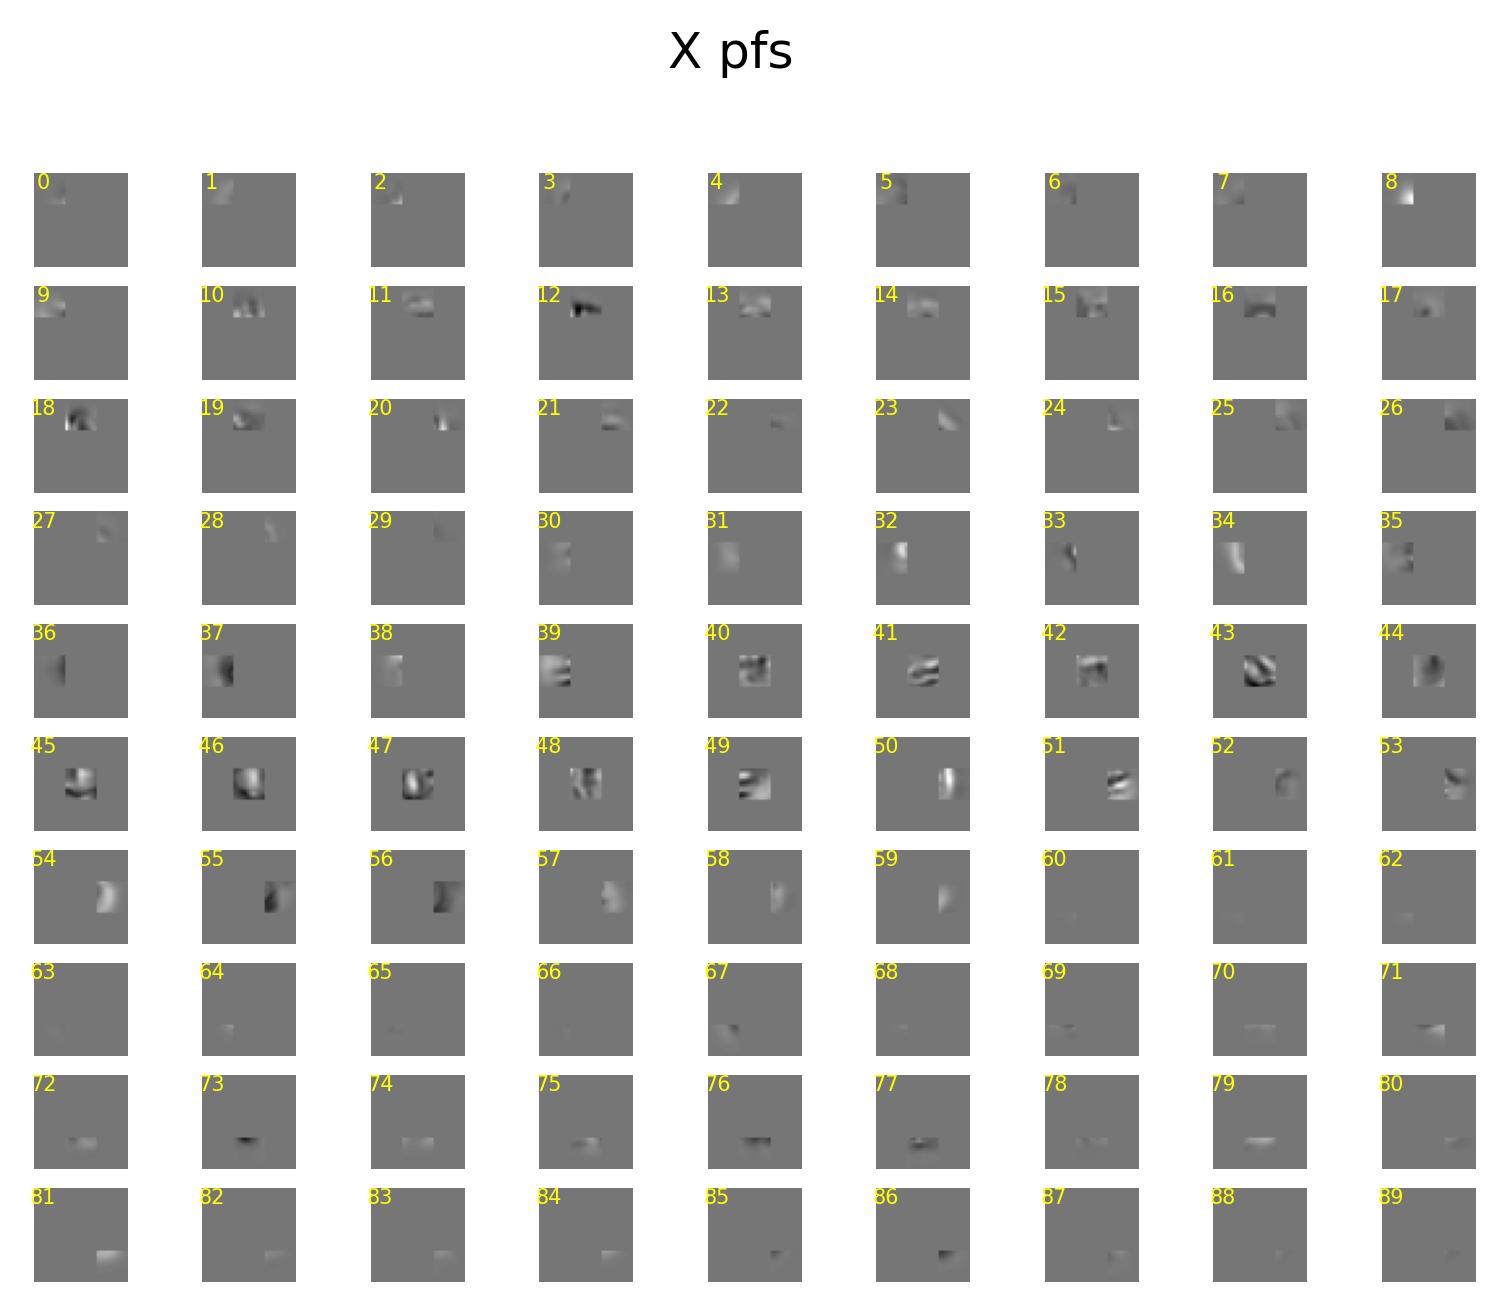

In [44]:
images = model.visualize_learned_X(nrows=x_visual_nrows, ncols=x_visual_ncols)